---
date: "2026-06-20"
date-modified: last-modified
format:
  html:
    toc: true
---


# The Poisson Distribution

## Intuition and Application
The Poisson distribution is a fundamental discrete probability distribution used to model "count data"—the number of times a specific event occurs within a continuous, fixed interval of time or space. 

It is the standard model for the **Law of Rare Events**. It applies when there is a massive number of opportunities for an event to occur (large $n$), but the probability of any single specific occurrence is exceedingly small (small $p$). 

**Examples:**

* The number of emails received in a given hour.
* The number of radioactive particles decaying in a millisecond.
* The number of typos per page in a large manuscript.

---

## Definition and PMF

**Definition:** A discrete [random variable](random-variables.ipynb) $X$ follows the Poisson distribution with rate parameter $\lambda > 0$, denoted $X \sim \text{Pois}(\lambda)$, if its Probability Mass Function (PMF) is given by:

$$P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!} \quad \text{for } k = 0, 1, 2, \dots$$

**Proof of Validity:**
To be a valid PMF, the probabilities must sum to 1. We use the Taylor series expansion for the exponential function, $\sum_{k=0}^{\infty} \frac{x^k}{k!} = e^x$:
$$\sum_{k=0}^{\infty} P(X = k) = \sum_{k=0}^{\infty} \frac{e^{-\lambda} \lambda^k}{k!} = e^{-\lambda} \left( \sum_{k=0}^{\infty} \frac{\lambda^k}{k!} \right) = e^{-\lambda} e^\lambda = 1 \quad \blacksquare$$

---

## Moments: Expected Value and Variance

A defining characteristic of the Poisson distribution is that its mean and variance are strictly equal to its parameter $\lambda$.

**Theorem:** If $X \sim \text{Pois}(\lambda)$, then $E(X) = \lambda$ and $Var(X) = \lambda$.

**Proof of Expected Value:**
$$E(X) = \sum_{k=0}^{\infty} k P(X=k) = \sum_{k=0}^{\infty} k \frac{e^{-\lambda} \lambda^k}{k!}$$
Since the term is $0$ when $k=0$, we start the index at $k=1$ and cancel $k$ with $k!$:
$$E(X) = e^{-\lambda} \sum_{k=1}^{\infty} \frac{\lambda^k}{(k-1)!}$$
Factor out one $\lambda$ to re-index the series:
$$E(X) = \lambda e^{-\lambda} \sum_{k=1}^{\infty} \frac{\lambda^{k-1}}{(k-1)!} = \lambda e^{-\lambda} \left( \sum_{j=0}^{\infty} \frac{\lambda^j}{j!} \right) = \lambda e^{-\lambda} e^\lambda = \lambda \quad \blacksquare$$

**Proof of Variance:**
We first find $E(X^2)$ using the factorial moment $E(X(X-1))$ to avoid messy series manipulation. By [LOTUS](lotus.ipynb#law-of-the-unconscious-statistician-lotus):
$$E(X(X-1)) = \sum_{k=0}^{\infty} k(k-1) \frac{e^{-\lambda} \lambda^k}{k!} = \sum_{k=2}^{\infty} \frac{e^{-\lambda} \lambda^k}{(k-2)!}$$
Factor out $\lambda^2$:
$$E(X(X-1)) = \lambda^2 e^{-\lambda} \sum_{k=2}^{\infty} \frac{\lambda^{k-2}}{(k-2)!} = \lambda^2 e^{-\lambda} e^\lambda = \lambda^2$$
We know $E(X(X-1)) = E(X^2) - E(X)$. Thus:
$$E(X^2) = E(X(X-1)) + E(X) = \lambda^2 + \lambda$$
Finally, apply the definition of variance:
$$Var(X) = E(X^2) - (E(X))^2 = (\lambda^2 + \lambda) - \lambda^2 = \lambda \quad \blacksquare$$

---

## Fundamental Theorems of the Poisson Distribution

### Theorem: Sum of Independent Poissons
If $X \sim \text{Pois}(\lambda_1)$ and $Y \sim \text{Pois}(\lambda_2)$ are independent, then their sum is perfectly Poisson distributed:
$$X + Y \sim \text{Pois}(\lambda_1 + \lambda_2)$$

**Proof (via Convolution):**
By the Law of Total Probability, we condition on the value of $X$:
$$P(X+Y = n) = \sum_{k=0}^{n} P(X=k)P(Y=n-k)$$
$$P(X+Y = n) = \sum_{k=0}^{n} \left( \frac{e^{-\lambda_1} \lambda_1^k}{k!} \right) \left( \frac{e^{-\lambda_2} \lambda_2^{n-k}}{(n-k)!} \right)$$
$$P(X+Y = n) = \frac{e^{-(\lambda_1+\lambda_2)}}{n!} \sum_{k=0}^{n} \frac{n!}{k!(n-k)!} \lambda_1^k \lambda_2^{n-k}$$
Recognizing the combination term $\binom{n}{k}$ and applying the Binomial Theorem $(a+b)^n = \sum \binom{n}{k} a^k b^{n-k}$:
$$P(X+Y = n) = \frac{e^{-(\lambda_1+\lambda_2)}}{n!} (\lambda_1 + \lambda_2)^n$$
This is precisely the PMF of a $\text{Pois}(\lambda_1 + \lambda_2)$ distribution. $\blacksquare$

### Theorem: Conditional Distribution Yields Binomial
If $X \sim \text{Pois}(\lambda_1)$ and $Y \sim \text{Pois}(\lambda_2)$ are independent, the conditional distribution of $X$ given $X+Y = n$ is Binomial.
$$X \mid (X+Y=n) \sim \text{Bin}\left(n, \frac{\lambda_1}{\lambda_1 + \lambda_2}\right)$$

**Proof:**
Using Bayes' Rule and Theorem 4.1:
$$P(X=k \mid X+Y=n) = \frac{P(X=k \cap X+Y=n)}{P(X+Y=n)} = \frac{P(X=k)P(Y=n-k)}{P(X+Y=n)}$$
Substitute the respective PMFs:
$$P(X=k \mid X+Y=n) = \frac{\frac{e^{-\lambda_1} \lambda_1^k}{k!} \frac{e^{-\lambda_2} \lambda_2^{n-k}}{(n-k)!}}{\frac{e^{-(\lambda_1+\lambda_2)} (\lambda_1+\lambda_2)^n}{n!}}$$
The exponential terms perfectly cancel. Rearranging the factorials yields $\binom{n}{k}$:
$$P(X=k \mid X+Y=n) = \binom{n}{k} \frac{\lambda_1^k \lambda_2^{n-k}}{(\lambda_1+\lambda_2)^n} = \binom{n}{k} \left(\frac{\lambda_1}{\lambda_1+\lambda_2}\right)^k \left(\frac{\lambda_2}{\lambda_1+\lambda_2}\right)^{n-k} \quad \blacksquare$$

---

## The Poisson Limit Theorem (Approximation to Binomial)

The Poisson distribution is the mathematical limit of the Binomial distribution as the number of trials goes to infinity while the expected number of successes remains constant. 

**Theorem:** If $X \sim \text{Bin}(n, p)$ such that as $n \to \infty$ and $p \to 0$, the expected value $\lambda = np$ remains strictly constant, then the PMF of $X$ converges to the PMF of a $\text{Pois}(\lambda)$ random variable.

**Proof:**
Start with the Binomial PMF and substitute $p = \frac{\lambda}{n}$:
$$P(X=k) = \binom{n}{k} p^k (1-p)^{n-k} = \frac{n(n-1)\dots(n-k+1)}{k!} \left(\frac{\lambda}{n}\right)^k \left(1-\frac{\lambda}{n}\right)^{n-k}$$
Group the terms strategically:
$$P(X=k) = \frac{\lambda^k}{k!} \left[ \frac{n}{n} \cdot \frac{n-1}{n} \cdots \frac{n-k+1}{n} \right] \left(1-\frac{\lambda}{n}\right)^n \left(1-\frac{\lambda}{n}\right)^{-k}$$
Now, take the limit as $n \to \infty$ with $k$ fixed:
1. The fraction block $\left[ \frac{n}{n} \dots \frac{n-k+1}{n} \right] \to 1^k = 1$.
2. The limit definition of the exponential function dictates $\lim_{n \to \infty} \left(1-\frac{\lambda}{n}\right)^n = e^{-\lambda}$.
3. The remaining term $\left(1-\frac{\lambda}{n}\right)^{-k} \to 1^{-k} = 1$.

Multiplying the limiting pieces together:
$$\lim_{n \to \infty} P(X=k) = \frac{\lambda^k}{k!} (1) (e^{-\lambda}) (1) = \frac{e^{-\lambda} \lambda^k}{k!} \quad \blacksquare$$

---

## Real-World Applications

**Example 1: Website Traffic**
A website receives 1 million independent visitors daily, each having a $p = 2 \times 10^{-6}$ chance of clicking a specific hidden easter egg. Because $n$ is massive and $p$ is tiny, we can completely bypass the computationally expensive Binomial coefficients and use the Poisson approximation with $\lambda = np = 2$.
The probability of exactly 3 people finding the easter egg is simply:
$$P(X = 3) \approx \frac{e^{-2} 2^3}{3!} = \frac{8}{6 e^2} \approx 0.180$$

**Example 2: The Birthday Problem (Multiple Matches)**
In a room of 1600 people, what is the probability that at least 4 people share the exact same day and hour of birth?
* Total possible subsets of 4 people: $n = \binom{1600}{4}$
* Probability a specific subset shares the same day-hour: $p = (1 / (365 \times 24))^3$
Because $n$ is extraordinarily large and $p$ is exceptionally small, calculating this exactly via Binomial distribution is practically impossible. However, defining $\lambda = np$ yields a highly accurate Poisson approximation in a single step.

---

## Python Visualizations

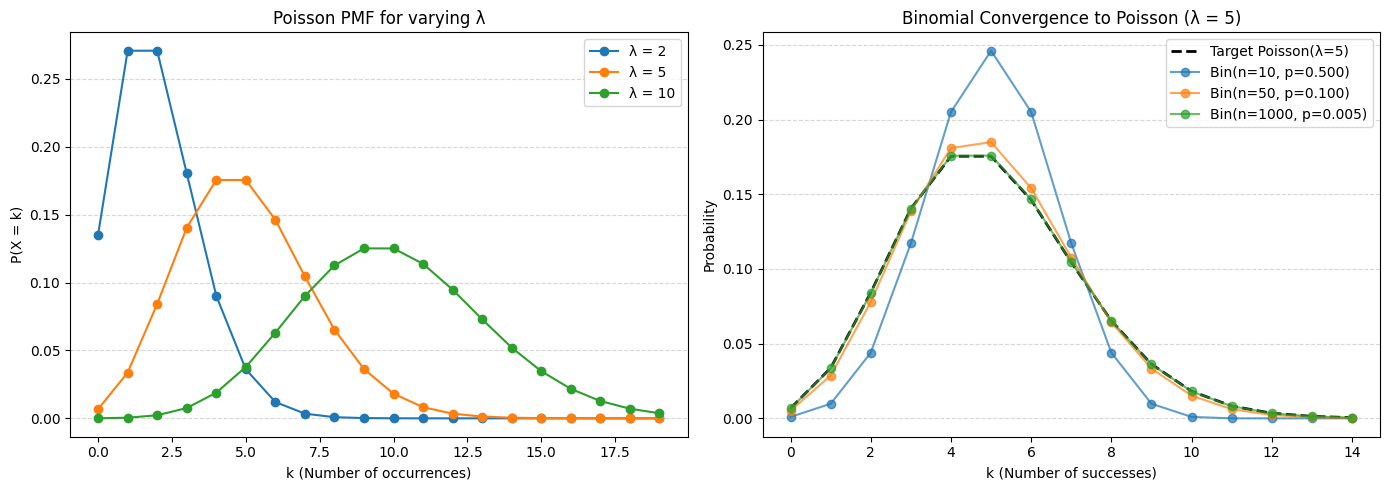

In [1]:
#| label: fig-poisson-dist
#| fig-cap: "Visualization of the Poisson PMF and the Poisson Limit Theorem."
#| echo: true
#| warning: false

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, binom

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plt.style.use('default')

# --- Plot 1: Shape of Poisson for various Lambdas ---
x_vals = np.arange(0, 20)
lambdas = [2, 5, 10]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for lam, col in zip(lambdas, colors):
    pmf = poisson.pmf(x_vals, mu=lam)
    axes[0].plot(x_vals, pmf, '-o', color=col, label=f'λ = {lam}')

axes[0].set_title("Poisson PMF for varying λ")
axes[0].set_xlabel("k (Number of occurrences)")
axes[0].set_ylabel("P(X = k)")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.5, linestyle='--')

# --- Plot 2: Binomial Convergence to Poisson ---
n_vals = [10, 50, 1000]
target_lambda = 5
x_limit = np.arange(0, 15)

# Plot the target Poisson distribution (Limit)
axes[1].plot(x_limit, poisson.pmf(x_limit, mu=target_lambda), 
             'k--', lw=2, label=f'Target Poisson(λ={target_lambda})')

# Plot Binomial approximations
for n in n_vals:
    p = target_lambda / n
    pmf = binom.pmf(x_limit, n, p)
    axes[1].plot(x_limit, pmf, '-o', alpha=0.7, label=f'Bin(n={n}, p={p:.3f})')

axes[1].set_title("Binomial Convergence to Poisson (λ = 5)")
axes[1].set_xlabel("k (Number of successes)")
axes[1].set_ylabel("Probability")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.5, linestyle='--')

plt.tight_layout()
plt.show()